# Guardrail Sandwich — LangGraph Implementation

> "For destructive actions, put a slice of bread on both sides."

This notebook implements Guardrail Sandwich as a **LangGraph `StateGraph`** — three explicit nodes connected by edges you can see and debug.

Everything is defined inline:

- the `SandwichState` TypedDict
- the hook functions and factories
- the three graph nodes (`pre_hooks`, `execute_tool`, `post_hooks`)
- the conditional routing logic
- mock and real walkthroughs

Default: AI Studio + `ernie-5.1` (OpenAI-compatible). See [`.env.example`](../../../.env.example) for provider config, [`model_config.py`](../../../model_config.py) for the shared model loader.

## What this pattern does

Guardrail Sandwich wraps a risky tool call with two deterministic layers:

1. **Pre-hooks** decide whether the action is allowed to run.
2. **The tool step** performs the action.
3. **Post-hooks** verify the result after the action runs.

In this graph version, each layer is an explicit node — you can see the flow in LangGraph Studio. In the [middleware version](../langchain/tutorial.ipynb), the same logic is an invisible interceptor inside `wrap_tool_call`.

| | `langgraph/` (StateGraph) | `langchain/` (Middleware) |
|---|---|---|
| **Mechanism** | Explicit nodes + edges, visible in LangGraph Studio | Invisible interceptors on the tool-call pipeline |
| **Best for** | Learning, debugging, custom topology | Shipping fast, adding guardrails to existing agents |
| **Trade-off** | More code, more control | Less code, less visibility |

## Setup

The notebook is mostly deterministic. The real-backend section at the end uses an LLM to parse free-text email into structured tool arguments. Default: AI Studio + `ernie-5.1` (OpenAI-compatible). Configure your provider in the root `.env` — see [`.env.example`](../../../.env.example).

In [1]:
from __future__ import annotations

import json
import operator
import os
import sys
from typing import Annotated, Any, Callable, TypedDict

# Make root and pattern folder importable
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "../../..")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

from dotenv import load_dotenv
from IPython.display import Image, display
from langchain_core.messages import AIMessage, AnyMessage, ToolMessage
from langchain_core.tools import StructuredTool
from langgraph.graph import END, START, StateGraph
from langgraph.prebuilt import ToolNode

# Shared hook factories — same definitions used by langchain/ notebook
from hooks import (
    HookPhase, HookResult,
    amount_threshold_hook, blocklist_hook, output_schema_hook,
)

print("Imports ready")

Imports ready


## State

Guardrail Sandwich does **not** need a large state. We track only the pieces that matter for the lesson:

- `tool_name` and `tool_args` describe the requested action
- `pre_outcomes` records the front guardrail decisions
- `tool_output` stores the tool result
- `post_outcomes` records the back guardrail decisions
- `final_status` is the final verdict

There is one extra field, `messages`, because `ToolNode` expects LangGraph message state. That is an implementation detail, not the main conceptual burden for the reader.

In [2]:
class SandwichState(TypedDict, total=False):
    # ToolNode requires a messages list in state.
    messages: Annotated[list[AnyMessage], operator.add]

    tool_name: str
    tool_args: dict[str, Any]

    # Single list of hook config dicts — each has {"name", "fn", "phase", "priority", "blocks", "applies_to"}.
    # Same shape as langchain/ hooks, plus a "phase" key for routing.
    hooks: list[dict[str, Any]]

    pre_outcomes: list[dict[str, Any]]
    tool_output: Any
    tool_error: str
    post_outcomes: list[dict[str, Any]]
    rollback_marked: bool
    final_status: str

ToolFn = Callable[..., Any]

print("State ready")

State ready


## `ToolNode`: the middle slice

We use LangGraph's prebuilt `ToolNode` as the middle node of the graph.

Why? Because the pattern is about **what happens before and after** the tool call. `ToolNode` already does the tool execution part well, so we should reuse it instead of rebuilding it.

Reference: [ToolNode docs](https://reference.langchain.com/python/langgraph.prebuilt/tool_node/ToolNode)

In [3]:
def make_tool_call_message(tool_name: str, tool_args: dict[str, Any], *, call_id: str = "guardrail-call") -> AIMessage:
    """Convert a simple tool request into the message format ToolNode expects.
    ToolNode reads AIMessage.tool_calls to decide which tool to invoke."""
    return AIMessage(
        content="",
        tool_calls=[{
            "name": tool_name,
            "args": tool_args,
            "id": call_id,
            "type": "tool_call",
        }],
    )

def decode_tool_message(message: ToolMessage) -> Any:
    """Turn ToolNode output back into plain Python data when possible.
    ToolNode stores structured return values inside ToolMessage.content as JSON strings."""
    text = message.content if isinstance(message.content, str) else str(message.content)
    stripped = text.strip()
    if stripped.startswith("{") or stripped.startswith("["):
        try:
            return json.loads(stripped)
        except json.JSONDecodeError:
            return text
    return text

print("ToolNode helpers ready")

ToolNode helpers ready


## Hook runner

`run_single_hook` is the graph-specific dispatcher. It reads `fn` from the hook config dict and handles fail-closed + shadow-mode semantics — same behavior as `GuardrailSandwichMiddleware._run_hook` in the langchain/ version.

The hook factories themselves (`amount_threshold_hook`, `blocklist_hook`, `output_schema_hook`) are imported from the shared [`hooks.py`](../hooks.py).

In [4]:
def run_single_hook(hook_cfg: dict[str, Any], tool_name: str, args: dict[str, Any], tool_output: Any) -> dict[str, Any]:
    """Run one hook and return a structured outcome dict.
    Same fail-closed + shadow-mode semantics as GuardrailSandwichMiddleware in langchain/."""
    fn = hook_cfg["fn"]
    try:
        result, reason = fn(tool_name, args, tool_output)
    except Exception as e:
        # Fail closed: crash → BLOCK
        return {
            "hook_name": hook_cfg["name"],
            "phase": hook_cfg["phase"],
            "result": HookResult.BLOCK.value,
            "reason": f"hook crashed: {type(e).__name__}: {e}",
        }

    # Shadow mode: blocks=False downgrades BLOCK to WARN
    if result == HookResult.BLOCK.value and not hook_cfg.get("blocks", True):
        return {
            "hook_name": hook_cfg["name"],
            "phase": hook_cfg["phase"],
            "result": HookResult.WARN.value,
            "reason": f"[shadow] {reason}",
        }

    return {
        "hook_name": hook_cfg["name"],
        "phase": hook_cfg["phase"],
        "result": result,
        "reason": reason,
    }

print("run_single_hook ready")

run_single_hook ready


## Node 1: pre-hooks

This node is the **front bread slice**. It decides whether the tool is allowed to run at all.

- If a pre-hook blocks, the graph ends immediately.
- If all pre-hooks pass, the node prepares the tool call message for `ToolNode`.

In [5]:
def pre_hooks_node(state: SandwichState) -> dict[str, Any]:
    tool_name = state["tool_name"]
    args = state.get("tool_args", {})
    hooks = state.get("hooks", [])

    # Filter by phase — the graph uses a single hooks list, unlike langchain/'s separate lists.
    pre_hooks = sorted(
        [h for h in hooks if h["phase"] == HookPhase.PRE.value],
        key=lambda h: h.get("priority", 100),
    )
    outcomes = []

    # Run hooks in priority order. First hard BLOCK stops the graph immediately.
    for hook_cfg in pre_hooks:
        outcome = run_single_hook(hook_cfg, tool_name, args, None)
        outcomes.append(outcome)
        if outcome["result"] == HookResult.BLOCK.value and hook_cfg.get("blocks", True):
            return {"pre_outcomes": outcomes, "final_status": "blocked_pre"}

    # All pre-hooks passed — prepare the tool call message for ToolNode.
    return {
        "pre_outcomes": outcomes,
        "messages": [make_tool_call_message(tool_name, args)],
    }

print("pre_hooks_node ready")

pre_hooks_node ready


## Node 2: tool execution

This is the only place where LangGraph-specific tool machinery really matters. We wrap our plain Python callables as tools, then hand execution to `ToolNode`.

In [6]:
def build_tool_node(tools: dict[str, ToolFn]) -> ToolNode:
    """Wrap plain callables as LangChain tools, then build a ToolNode."""
    wrapped = [
        StructuredTool.from_function(fn, name=name, description=fn.__doc__ or name)
        for name, fn in tools.items()
    ]
    # handle_tool_errors=True makes ToolNode return an error ToolMessage
    # instead of re-raising into the graph runtime. That keeps the pattern
    # logic in one place: post_hooks_node can normalize the failure.
    return ToolNode(wrapped, handle_tool_errors=True)

print("ToolNode builder ready")

ToolNode builder ready


## Node 3: post-hooks

This node is the **back bread slice**. It reads the `ToolMessage` appended by `ToolNode`, decodes the tool output, and runs the post-hooks.

If the tool step itself failed, we normalize that back to the simple pattern-level status `tool_failed`.

In [7]:
def post_hooks_node(state: SandwichState) -> dict[str, Any]:
    tool_name = state["tool_name"]
    args = state.get("tool_args", {})
    hooks = state.get("hooks", [])

    last_message = state["messages"][-1]

    # ToolNode signals failures via ToolMessage(status="error").
    if isinstance(last_message, ToolMessage) and getattr(last_message, "status", None) == "error":
        error_text = str(last_message.content)
        if "not a valid tool" in error_text:
            error_text = f"unknown tool {tool_name!r}"
        return {
            "tool_error": error_text,
            "post_outcomes": [],
            "rollback_marked": False,
            "final_status": "tool_failed",
        }

    tool_output = decode_tool_message(last_message) if isinstance(last_message, ToolMessage) else last_message

    post_hooks = sorted(
        [h for h in hooks if h["phase"] == HookPhase.POST.value],
        key=lambda h: h.get("priority", 100),
    )
    outcomes = []
    rollback = False

    # All post-hooks run for audit completeness, even after a BLOCK.
    for hook_cfg in post_hooks:
        outcome = run_single_hook(hook_cfg, tool_name, args, tool_output)
        outcomes.append(outcome)
        if outcome["result"] == HookResult.BLOCK.value and hook_cfg.get("blocks", True):
            rollback = True

    return {
        "tool_output": tool_output,
        "post_outcomes": outcomes,
        "rollback_marked": rollback,
        "final_status": "blocked_post" if rollback else "passed",
    }

print("post_hooks_node ready")

post_hooks_node ready


## Build the graph

The graph is deliberately small and explicit:

`START -> pre_hooks -> (blocked? END : execute_tool) -> post_hooks -> END`

In [8]:
def route_after_pre_hooks(state: SandwichState) -> str:
    """Skip the tool step when a pre-hook already blocked the request."""
    return "end" if state.get("final_status") == "blocked_pre" else "execute_tool"

def build_guardrail_graph(tools: dict[str, ToolFn], hooks: list[dict[str, Any]]):
    """Build the sandwich graph. hooks is a list of config dicts with fn inlined."""
    graph = StateGraph(SandwichState)
    graph.add_node("pre_hooks", pre_hooks_node)
    graph.add_node("execute_tool", build_tool_node(tools))
    graph.add_node("post_hooks", post_hooks_node)
    graph.add_edge(START, "pre_hooks")
    graph.add_conditional_edges("pre_hooks", route_after_pre_hooks, {"end": END, "execute_tool": "execute_tool"})
    graph.add_edge("execute_tool", "post_hooks")
    graph.add_edge("post_hooks", END)
    return graph.compile()

print("Graph builder ready")

Graph builder ready


## Mock tools

We use one healthy tool and one broken tool so readers can see both sides of the sandwich with very little setup.

In [9]:
def transfer_funds(account: str = "", amount: float = 0, memo: str = "") -> dict:
    """Simulate a successful transfer."""
    # A healthy receipt includes the fields our downstream system expects.
    return {"status": "ok", "account": account, "amount": amount, "tx_id": "TX-20250609-001"}

def broken_transfer_funds(account: str = "", amount: float = 0, memo: str = "") -> dict:
    """Simulate a buggy transfer that forgets tx_id."""
    # This intentionally breaks the schema so the post-hook has something to catch.
    return {"status": "ok", "account": account, "amount": amount}

print("Mock tools ready")

Mock tools ready


## Assemble the demo

Same hooks as the langchain/ version:

- `amount_threshold` (PRE) — blocks transfers over 1M
- `blocklist` (PRE) — blocks sanctioned accounts
- `output_schema` (POST) — blocks receipts missing required keys

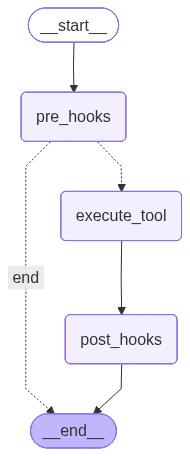

In [10]:
# Hook configs — imported from shared hooks.py, fn inlined in each dict.
all_hooks = [
    amount_threshold_hook("amount", 1_000_000),
    blocklist_hook("account", {"BLOCKED-999", "SANCTIONED-001"}),
    output_schema_hook(["status", "tx_id"]),
]

# One graph with the healthy tool, one with the broken tool.
sandwich = build_guardrail_graph({"transfer": transfer_funds}, all_hooks)
broken_sandwich = build_guardrail_graph({"transfer": broken_transfer_funds}, all_hooks)

display(Image(data=sandwich.get_graph().draw_mermaid_png(), alt="Guardrail Sandwich LangGraph graph"))

## Small trace printer

The trace is intentionally short. It should help readers see the verdict quickly without turning the notebook into a log dump.

In [11]:
def print_trace(label: str, result: dict) -> None:
    print(f"\n{label}")
    print("-" * len(label))
    print("final_status:", result.get("final_status"))
    print("tool_output :", result.get("tool_output"))
    if result.get("tool_error"):
        print("tool_error  :", result.get("tool_error"))
    for key in ["pre_outcomes", "post_outcomes"]:
        if result.get(key):
            print(f"{key}:")
            for outcome in result[key]:
                print("  -", outcome["hook_name"], outcome["result"], "->", outcome["reason"])

print("Trace printer ready")

Trace printer ready


## Mock run 1: routine transfer passes

In [12]:
result_ok = sandwich.invoke({
    "tool_name": "transfer",
    "tool_args": {"account": "CORP-1234", "amount": 4200, "memo": "Invoice #42"},
    "hooks": all_hooks,
})
print_trace("Mock run 1: routine transfer", result_ok)


Mock run 1: routine transfer
----------------------------
final_status: passed
tool_output : {'status': 'ok', 'account': 'CORP-1234', 'amount': 4200.0, 'tx_id': 'TX-20250609-001'}
pre_outcomes:
  - amount_threshold pass -> amount=4200 within limit
  - blocklist pass -> account clear
post_outcomes:
  - output_schema pass -> output schema valid


## Mock run 2: pre-hook blocks the action

In [13]:
result_blocked_pre = sandwich.invoke({
    "tool_name": "transfer",
    "tool_args": {"account": "CORP-1234", "amount": 5_000_000, "memo": "Large transfer"},
    "hooks": all_hooks,
})
print_trace("Mock run 2: threshold block", result_blocked_pre)


Mock run 2: threshold block
---------------------------
final_status: blocked_pre
tool_output : None
pre_outcomes:
  - amount_threshold block -> amount=5000000 exceeds 1000000


## Mock run 3: blocklist blocks a sanctioned account

In [14]:
result_blocklist = sandwich.invoke({
    "tool_name": "transfer",
    "tool_args": {"account": "SANCTIONED-001", "amount": 500, "memo": "Advisory fee"},
    "hooks": all_hooks,
})
print_trace("Mock run 3: blocklist block", result_blocklist)


Mock run 3: blocklist block
---------------------------
final_status: blocked_pre
tool_output : None
pre_outcomes:
  - amount_threshold pass -> amount=500 within limit
  - blocklist block -> account='SANCTIONED-001' on blocklist


## Mock run 4: post-hook catches a bad receipt

In [15]:
result_blocked_post = broken_sandwich.invoke({
    "tool_name": "transfer",
    "tool_args": {"account": "CORP-1234", "amount": 4200, "memo": "Invoice #42"},
    "hooks": all_hooks,
})
print_trace("Mock run 4: bad receipt schema", result_blocked_post)


Mock run 4: bad receipt schema
------------------------------
final_status: blocked_post
tool_output : {'status': 'ok', 'account': 'CORP-1234', 'amount': 4200.0}
pre_outcomes:
  - amount_threshold pass -> amount=4200 within limit
  - blocklist pass -> account clear
post_outcomes:
  - output_schema block -> output missing keys: ['tx_id']


## Real backend

The model is used only to extract tool arguments from free-text email. The guardrails remain deterministic and identical to the mock runs.

Default: AI Studio + `ernie-5.1` (OpenAI-compatible). Configure in root `.env` — see [`.env.example`](../../../.env.example).

In [16]:
# Shared model loader — registers CN providers (AI Studio, DashScope, etc.)
from model_config import get_model

model = get_model()

Model: ernie:ernie-5.1


In [17]:
email = """
Hi ops team,

Please transfer JPY 4,200 to vendor account CORP-1234 for invoice #42.
Memo: office supplies.
"""

print(email)


Hi ops team,

Please transfer JPY 4,200 to vendor account CORP-1234 for invoice #42.
Memo: office supplies.



## Real run 1: let the model extract tool arguments

In [18]:
transfer_args = None

if model:
    prompt = f"""Extract one transfer request from the email below.
Return JSON with exactly these keys: account, amount, memo.
Return JSON only.

Email:
{email}
"""
    try:
        response = model.invoke(prompt)
        transfer_args = json.loads(response.content)
        print(json.dumps(transfer_args, indent=2))
    except Exception as e:
        print(f"Model call failed: {type(e).__name__}: {e}")
else:
    print("Skipping — no API key set.")

Model call failed: JSONDecodeError: Expecting value: line 1 column 1 (char 0)


## Real run 2: feed those args through the same sandwich

In [19]:
if transfer_args:
    result_real = sandwich.invoke({
        "tool_name": "transfer",
        "tool_args": transfer_args,
        "hooks": all_hooks,
    })
    print_trace("Real run: extracted transfer", result_real)
else:
    print("No extracted args available.")

No extracted args available.


## Composing as a subgraph

The compiled sandwich graph can be embedded as a node in a larger agent graph. This is how you'd add guardrails to a `create_react_agent` pipeline:

```python
from langgraph.prebuilt import create_react_agent

# The sandwich graph is a compiled StateGraph — it can be used as a subgraph node.
# Wrap it so the parent agent routes destructive tool calls through the sandwich
# while letting safe tools (read_balance, get_rate) execute directly.

parent = StateGraph(...)
parent.add_node("react_agent", create_react_agent(model, safe_tools))
parent.add_node("guardrail_sandwich", sandwich)  # compiled graph as a node
parent.add_conditional_edges("react_agent", route_by_risk, {...})
```

LangGraph also ships prebuilt middleware that works alongside custom graphs — see the [middleware version](../langchain/tutorial.ipynb) for `PIIMiddleware`, `HumanInTheLoopMiddleware`, etc.

## What to remember

- `StateGraph` makes the sandwich flow explicit: `pre_hooks → execute_tool → post_hooks` as visible nodes and edges.
- `ToolNode` handles tool execution — spend notebook space on the pattern, not framework plumbing.
- `add_conditional_edges` implements the skip logic: if pre-hooks block, the graph jumps to `END` without running the tool.
- Hook crash = `BLOCK`, not `PASS`. A broken guardrail must not become an open door.
- The compiled graph is a first-class object — embed it as a subgraph in larger agent pipelines.

## Further reading

- [Middleware version](../langchain/tutorial.ipynb) — the same Guardrail Sandwich pattern implemented as LangChain v1 middleware with `@wrap_tool_call` and `AgentMiddleware`, tested via `create_agent`
- [Parent pattern README](../../README.md) — full design rationale, failure mode taxonomy, hook contract specification, and engineering references for the pure-Python implementation
- [REFERENCE_IMPL.md](../../../REFERENCE_IMPL.md) — how to install `uv`, sync dependencies, launch JupyterLab, and run all tutorial notebooks
- [ToolNode reference](https://langchain-ai.github.io/langgraph/reference/prebuilt/#langgraph.prebuilt.tool_node.ToolNode) — the prebuilt LangGraph node that executes tool calls from `AIMessage.tool_calls`, with error handling and message state management
- [StateGraph reference](https://langchain-ai.github.io/langgraph/reference/graphs/#langgraph.graph.state.StateGraph) — the core LangGraph primitive for building typed state machines with nodes, edges, and conditional routing
- [Graph.draw_mermaid_png](https://langchain-ai.github.io/langgraph/how-tos/visualization/) — how to visualize LangGraph graphs as Mermaid diagrams or PNG images for debugging and documentation
- [OWASP Top 10 for Agentic Applications](https://genai.owasp.org/) — security risks specific to LLM agents, including tool misuse, excessive autonomy, and prompt injection — the threats guardrails are designed to mitigate